# 01: Analyze LLM Architectures

This tutorial aims to analyze the component inside  LLMs. This is very important when working with LLMs to debug the model and know their capabilities and limits.

## 1. Imports

In [1]:
import matplotlib.pyplot as plt
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

## 2. Utils

The utils functions help for:
- Load from a list of (small) models.  eel free to try other models until the GPU memory is not enough!
- Make plots.
- Iterate over evaluation and model configurations.

In [2]:
def plot_module_stats(data_dict, x_label, y_label, title):
    """
    Creates a bar plot to visualize module statistics.

    Args:
        data_dict (dict): Dictionary containing the data to plot, where keys are labels and values are the corresponding values
        x_label (str): Label for the x-axis
        y_label (str): Label for the y-axis
        title (str): Title of the plot

    Returns:
        None: Displays the plot using matplotlib
    """
    plt.figure(figsize=(10, 6))
    plt.bar(data_dict.keys(), data_dict.values())
    plt.xticks(rotation=45, ha="right")
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [4]:
model_ids = [
    "facebook/opt-125m",
    "facebook/opt-350m",
    "facebook/opt-1.3b",
    "facebook/opt-2.7b",
    "meta-llama/Llama-3.2-1B",
    "meta-llama/Llama-3.2-1B-Instruct",
    "meta-llama/Llama-3.2-3B-Instruct",
    "google/gemma-3-1b-it",
    "google/gemma-3-4b-it",
    "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B",
    # "microsoft/Phi-4-mini-instruct",
    # "HuggingFaceTB/SmolLM-135M",
    # "HuggingFaceTB/SmolLM-135M-instruct",
    # "HuggingFaceTB/SmolLM-360M",
    # "HuggingFaceTB/SmolLM-360M-Instruct",
    # "HuggingFaceTB/SmolLM-1.7B",
    # "HuggingFaceTB/SmolLM-1.7B-Instruct",
    # "HuggingFaceTB/SmolLM2-135M",
    # "HuggingFaceTB/SmolLM2-135M-Instruct",
    # "HuggingFaceTB/SmolLM2-360M",
    # "HuggingFaceTB/SmolLM2-360M-Instruct",
    # "HuggingFaceTB/SmolLM2-1.7B",
    # "HuggingFaceTB/SmolLM2-1.7B-Instruct",
    # "PleIAs/Pleias-350m-Preview",
    # "PleIAs/Pleias-Pico",
    # "PleIAs/Pleias-1.2b-Preview",
    # "PleIAs/Pleias-Nano",
    # "PleIAs/Pleias-3b-Preview",
]

# Load the one model from the list
model_id = model_ids[0]
model = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype="auto").cuda()
tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer

GPT2TokenizerFast(name_or_path='facebook/opt-125m', vocab_size=50265, model_max_length=1000000000000000019884624838656, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '</s>', 'eos_token': '</s>', 'unk_token': '</s>', 'pad_token': '<pad>'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	1: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
}
)

## 3. Analyze LLM architectures

### 3.1 General LLM information

**Implementation task:**
- Implement the function `get_model_info` to get the general information of the LLM model.
- Extract the information for multiple LLMs.

**Questions:**
- What is the hidden size?
- How many attention heads?
- How many layers?
- What is the vocab size?
- What is the model type?
- What is the architecture?
- What is the max context length?

In [8]:
def get_model_info(model):
    """
    Returns basic information about the loaded LLM model.

    Args:
        model: The loaded model

    Returns:
        dict: Dictionary containing model information
    """
    ### To Complete ###
    model_config = model.config
    info = {
        "hidden_size": model_config.hidden_size,
        "num_attention_heads": model_config.num_attention_heads,
        "num_hidden_layers": model_config.num_hidden_layers,
        "vocab_size": model_config.vocab_size,
        "model_type": model_config.model_type,
        "architecture": type(model).__name__,
        "max_context_length": model_config.max_position_embeddings,
    }
    ### End of To Complete ###

    return info

In [7]:
model_info = get_model_info(model)
model_info

{'hidden_size': 768,
 'num_attention_heads': 12,
 'num_hidden_layers': 12,
 'vocab_size': 50272,
 'model_type': 'opt',
 'architecture': 'OPTForCausalLM',
 'max_context_length': 2048}

### 3.2 Tokenization

**Implementation task:**
- Use the tokenizer to tokenize an input sentence with typos and without typos (or other input variations).
- Repeat the experiment for multiple LLMs.

**Questions:**
- How does input sentence mistakes impact the tokenization?
- Does it impact the model performance?

In [9]:
# Test sentences - one with typos and one without
correct_sentence = "The quick brown fox jumps over the lazy dog."
typo_sentence = "Teh quik brwn fox jmps ovr the lzy dog."

### To Complete ###
tokens_correct = tokenizer(correct_sentence, return_tensors="pt")
tokens_typo = tokenizer(typo_sentence, return_tensors="pt")

print("Correct sentence tokens:")
print(tokenizer.convert_ids_to_tokens(tokens_correct["input_ids"][0]))
print("\nTypo sentence tokens:")
print(tokenizer.convert_ids_to_tokens(tokens_typo["input_ids"][0]))
### End of To Complete ###

Correct sentence tokens:
['</s>', 'The', 'Ġquick', 'Ġbrown', 'Ġfox', 'Ġjumps', 'Ġover', 'Ġthe', 'Ġlazy', 'Ġdog', '.']

Typo sentence tokens:
['</s>', 'Te', 'h', 'Ġqu', 'ik', 'Ġbr', 'wn', 'Ġfox', 'Ġj', 'm', 'ps', 'Ġov', 'r', 'Ġthe', 'Ġl', 'zy', 'Ġdog', '.']


### 3.3 LLM modules

**Implementation task:**
- Implement a function that identifies and counts the module of each type in the model.
- Repeat the experiment for multiple LLMs.

**Questions:**
- What does each module do?
- What are the modules that are here only once?
- What are the modules that are here multiple times?
- What is the most common module?

In [10]:
def count_modules(model):
    """Count the number of each type of module in the model.

    Args:
        model: The PyTorch model to analyze

    Returns:
        dict: A dictionary mapping module type names to their counts
    """
    module_counts = {}
    ### To Complete ###
    for name, module in model.named_modules():
        module_type = type(module).__name__
        module_counts[module_type] = module_counts.get(module_type, 0) + 1
    ### End of To Complete ###
    return module_counts

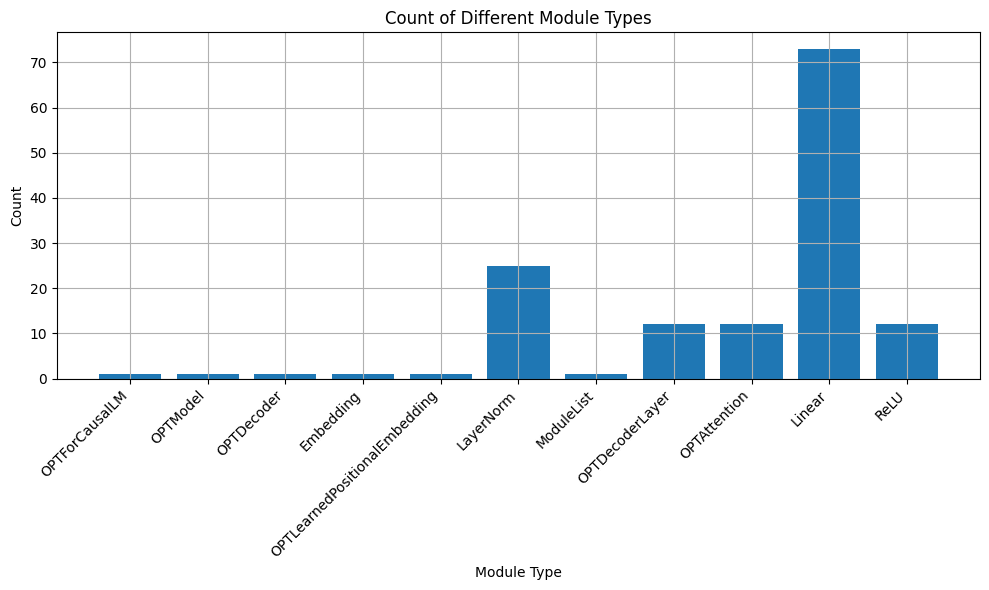

In [11]:
module_counts = count_modules(model)

plot_module_stats(
    module_counts,
    x_label="Module Type",
    y_label="Count",
    title="Count of Different Module Types",
)

### 3.4 LLM parameters

**Implementation task:**
- Implement a function that counts the paramter in each module type in the model.
- Repeat the experiment for multiple LLMs.

**Questions:**
- What are the modules with the least parameters?
- What are the modules with the most parameters?
- How many parameters are there in each module?
- What is the layer type with the most parameters?

In [12]:
def count_module_parameters(model):
    """Count the number of parameters in each module type in the model.

    Args:
        model: The PyTorch model to analyze

    Returns:
        dict: A dictionary mapping module type names to their total parameter counts
    """
    module_parameters = {}
    ### To Complete ###
    for name, module in model.named_modules():
        module_type = type(module).__name__
        num_params = sum(p.numel() for p in module.parameters())
        module_parameters[module_type] = (
            module_parameters.get(module_type, 0) + num_params
        )
    ### End of To Complete ###
    return module_parameters

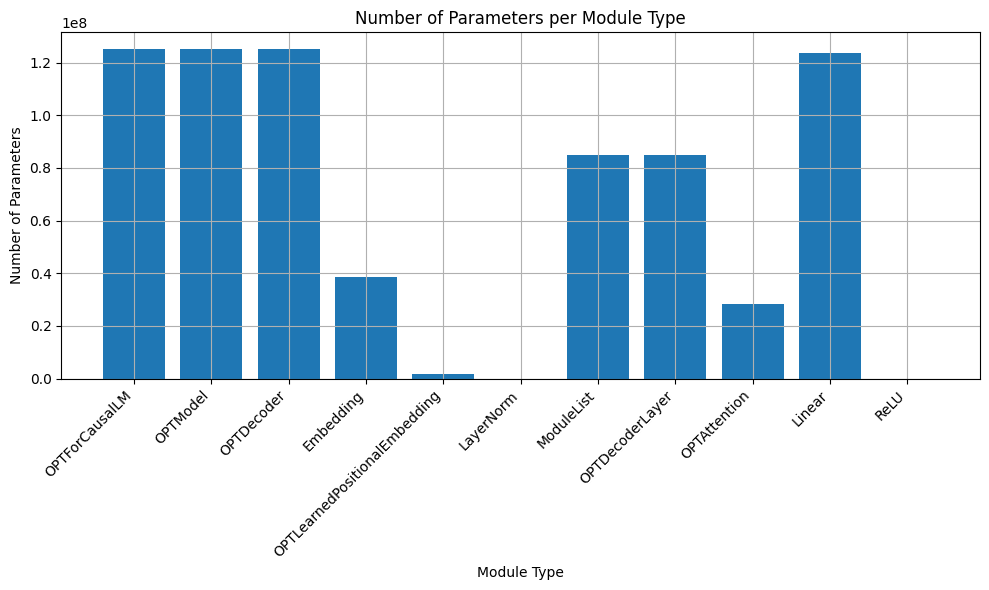

In [13]:
module_parameters = count_module_parameters(model)

plot_module_stats(
    module_parameters,
    x_label="Module Type",
    y_label="Number of Parameters",
    title="Number of Parameters per Module Type",
)

**Implementation task:**
- Implement a function that returns the precision of the parameters in each module type (that has parameters) in the model.
- Repeat the experiment for multiple LLMs.

**Questions:**
- What is the precision of the parameters in each module?

In [ ]:
def get_module_precisions(model):
    """
    Returns a dictionary mapping module types to their parameter precision/dtype.

    Args:
        model: PyTorch model

    Returns:
        dict: Mapping of module type names to their parameter dtype
    """
    module_dtypes = {}
    ### To Complete ###
    for name, module in model.named_modules():
        if list(module.parameters()):  # Only check modules with parameters
            module_type = type(module).__name__
            dtype = next(module.parameters()).dtype
            if module_type not in module_dtypes:
                if module_type in module_dtypes and module_dtypes[module_type] != dtype:
                    print(
                        f"Warning: Mixed precision detected for {module_type} - found both {module_dtypes[module_type]} and {dtype}"
                    )
                module_dtypes[module_type] = dtype
    ### End of To Complete ###
    return module_dtypes

In [15]:
module_precisions = get_module_precisions(model)
for module_type, dtype in module_precisions.items():
    print(f"- {module_type} parameters dtype: {dtype}")

- OPTForCausalLM parameters dtype: torch.float16
- OPTModel parameters dtype: torch.float16
- OPTDecoder parameters dtype: torch.float16
- Embedding parameters dtype: torch.float16
- OPTLearnedPositionalEmbedding parameters dtype: torch.float16
- LayerNorm parameters dtype: torch.float16
- ModuleList parameters dtype: torch.float16
- OPTDecoderLayer parameters dtype: torch.float16
- OPTAttention parameters dtype: torch.float16
- Linear parameters dtype: torch.float16


**Implementation task:**
- Implement a function that combines the number of parameters and the precision of the parameters in each module type to estimate the memory footprint of the model.
- Repeat the experiment for multiple LLMs.

**Questions:**
- What is the estimated memory footprint of the model based on the precision and number of parameters of each module?
- What are the limits of this estimation?

In [16]:
def estimate_memory_footprint(module_parameters, module_precisions):
    """
    Estimates the memory footprint of a model based on parameter counts and precisions.

    Args:
        module_parameters: Dict mapping module types to parameter counts
        module_precisions: Dict mapping module types to parameter dtypes

    Returns:
        dict: Memory usage in bytes for each module type
        float: Total memory usage in bytes
    """
    ### To Complete ###
    dtype_sizes = {
        torch.float16: 2,  # 16-bit = 2 bytes
        torch.float32: 4,  # 32-bit = 4 bytes
        torch.float64: 8,  # 64-bit = 8 bytes
        torch.int8: 1,  # 8-bit = 1 byte
        torch.int16: 2,  # 16-bit = 2 bytes
        torch.int32: 4,  # 32-bit = 4 bytes
        torch.int64: 8,  # 64-bit = 8 bytes
    }

    memory_usage = {}
    total_memory = 0

    for module_type in module_parameters:
        if module_type in module_precisions:
            dtype = module_precisions[module_type]
            num_params = module_parameters[module_type]
            bytes_per_param = dtype_sizes.get(
                dtype, 4
            )  # Default to 4 bytes if dtype not found
            memory = num_params * bytes_per_param
            memory_usage[module_type] = memory
            total_memory += memory
    ### End of To Complete ###
    return memory_usage, total_memory

In [18]:
estimate_memory_footprint(module_parameters, module_precisions)

({'OPTForCausalLM': 250478592,
  'OPTModel': 250478592,
  'OPTDecoder': 250478592,
  'Embedding': 77217792,
  'OPTLearnedPositionalEmbedding': 3148800,
  'LayerNorm': 76800,
  'ModuleList': 170108928,
  'OPTDecoderLayer': 170108928,
  'OPTAttention': 56696832,
  'Linear': 247252992},
 1476046848)

**Implementation task:**
- Implement plotting functions that represent the parameters of the model in the form of a heatmap of absolute values and a distribution.
- Repeat the experiment for multiple LLMs.

**Questions:**
- Does the parameter heatmap shows some patterns?
- Does the parameter distribution shows some patterns?

In [21]:
def plot_weight_heatmap_and_distribution(
    model, module_name: str, title: str = None
) -> None:
    """
    Plot side-by-side the heatmap of absolute weight values and the distribution of weights
    for a specific module in the model.

    Args:
        model: PyTorch model
        module_name: Name of the module to analyze
        title: Optional title for the plot
    """
    import matplotlib.pyplot as plt
    import numpy as np

    for name, module in model.named_modules():
        if name == module_name and hasattr(module, "weight"):
            # Extract weights
            weights = module.weight.detach().cpu().numpy()
            abs_weights = np.abs(weights)
            flat_weights = weights.flatten()

            # Create side-by-side plots
            fig, axes = plt.subplots(1, 2, figsize=(16, 6))

            # Heatmap of absolute weights
            im = axes[0].imshow(abs_weights, cmap="viridis", aspect="auto")
            plt.colorbar(im, ax=axes[0])
            axes[0].set_title(
                (title + " - Heatmap") if title else f"Weight Heatmap for {name}"
            )
            axes[0].set_xlabel("Input Features")
            axes[0].set_ylabel("Output Features")

            # Distribution of weights
            axes[1].hist(
                flat_weights, bins=100, density=True, color="tab:blue", alpha=0.7
            )
            axes[1].set_title(
                (title + " - Distribution")
                if title
                else f"Distribution of Weights in {name}"
            )
            axes[1].set_xlabel("Weight Value")
            axes[1].set_ylabel("Density")
            axes[1].grid(True)

            plt.tight_layout()
            plt.show()
            break

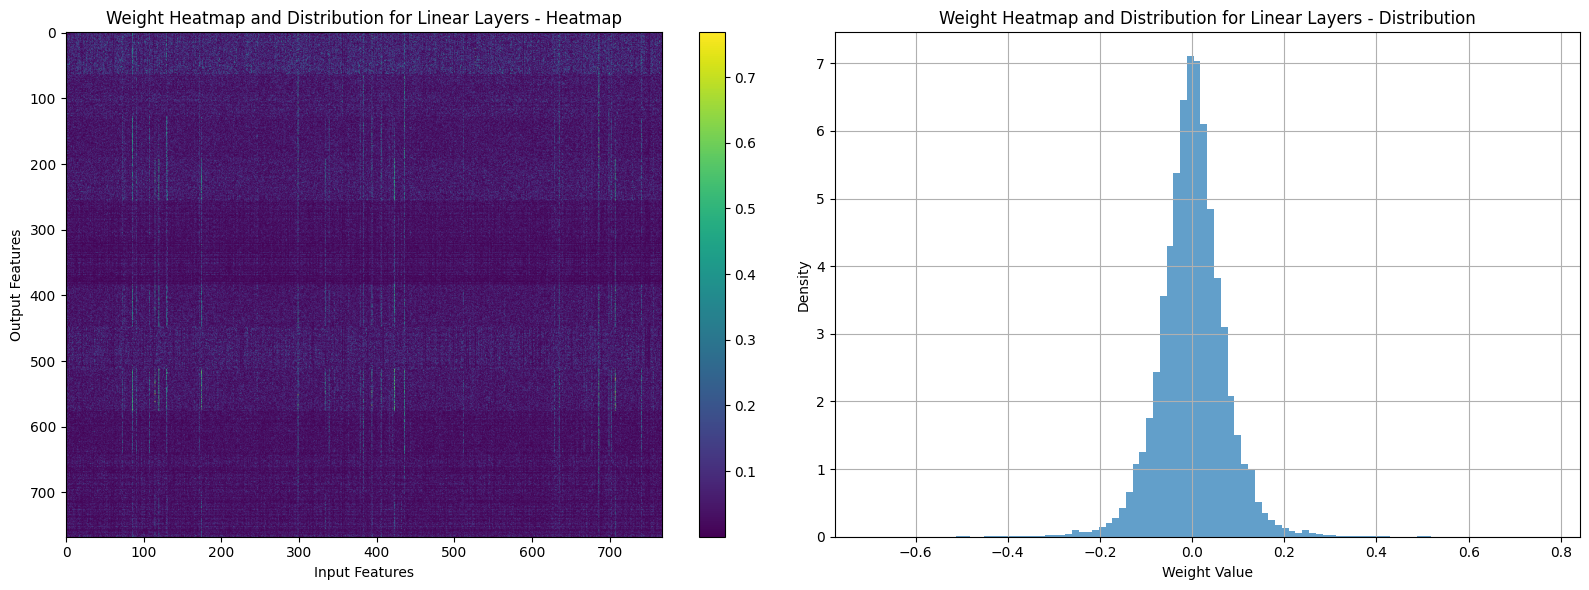

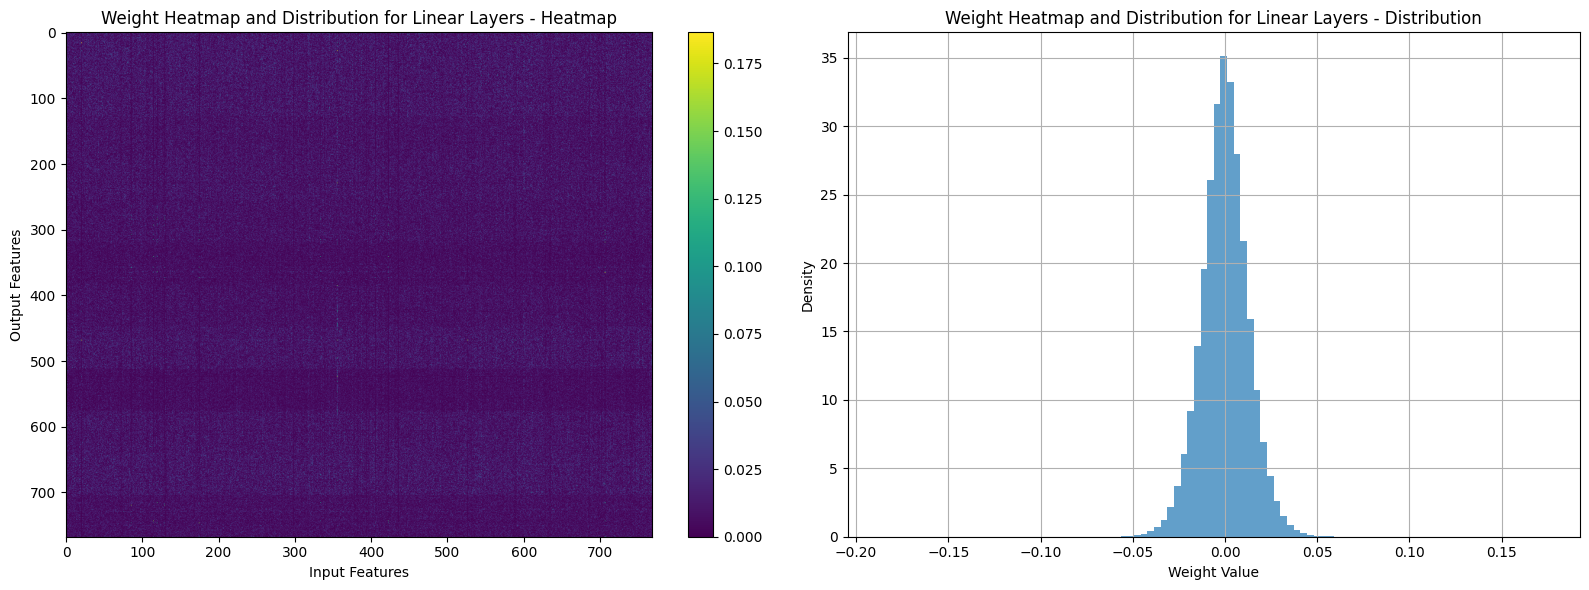

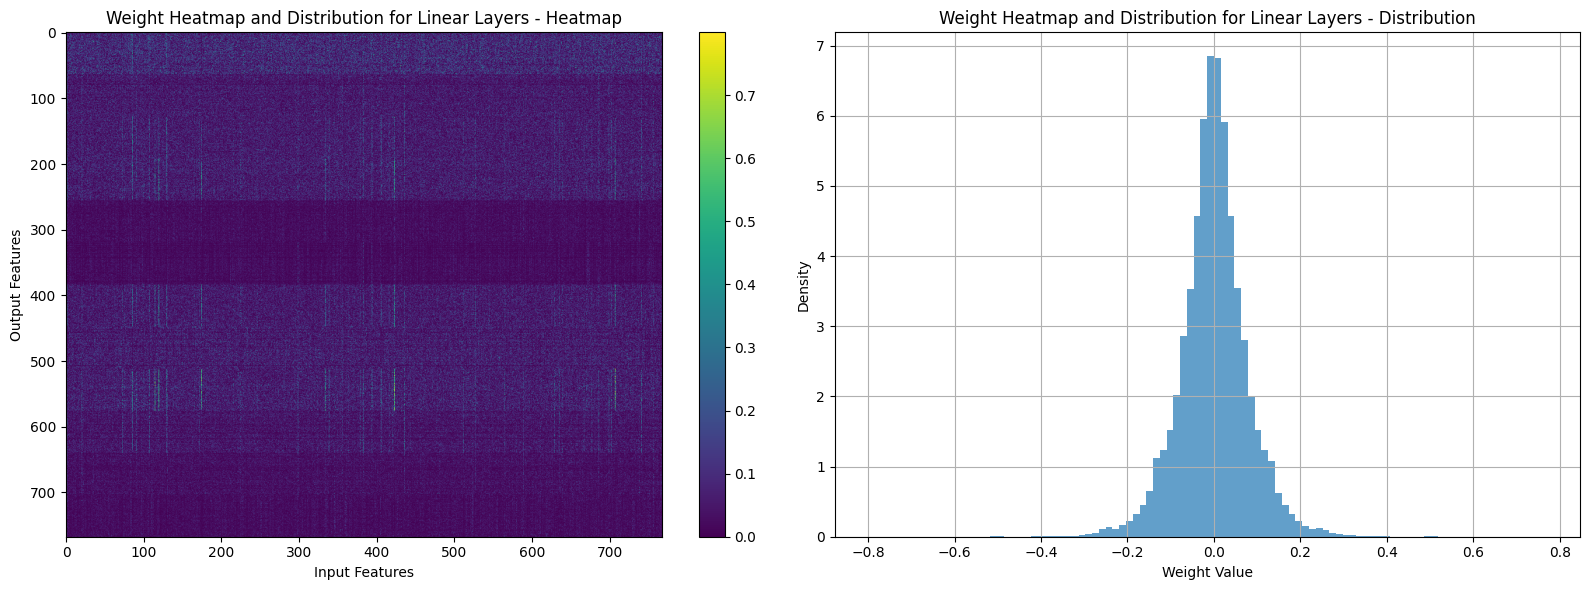

In [22]:
for i, (name, module) in enumerate(model.named_modules()):
    if isinstance(module, torch.nn.Linear):
        plot_weight_heatmap_and_distribution(
            model, name, title="Weight Heatmap and Distribution for Linear Layers"
        )
    if i > 10:
        break

### 3.5 LLM activations

**Implementation task:**
- Implement a function that collects the activations of the model for a specific input sentence.
- Repeat the experiment for multiple LLMs.

**Questions:**
- What is the shape of the activations?

In [23]:
def collect_activations(model, tokenizer, prompt):
    """
    Collect activation values when processing an input prompt through the model.

    Args:
        model: PyTorch model
        tokenizer: Tokenizer
        prompt: Input text prompt

    Returns:
        Dictionary mapping layer names to their activation values
    """
    activations = {}

    ### To Complete ###
    # Hook function to capture activations
    def hook_fn(name):
        def hook(module, input, output):
            activations[name] = (
                output.detach().cpu()
            )  # Shape: (batch_size, sequence_length, hidden_size)

        return hook

    # Register hooks for all modules
    handles = []
    for name, module in model.named_modules():
        if isinstance(module, (torch.nn.Linear, torch.nn.LayerNorm)):
            handle = module.register_forward_hook(hook_fn(name))
            handles.append(handle)

    # Process input through model
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model(**inputs)

    # Remove hooks
    for handle in handles:
        handle.remove()
    ### End of To Complete ###

    return activations

In [24]:
prompt = "Hello, how are you?"
layer_activations = collect_activations(model, tokenizer, prompt)

# Print activation shapes for each layer
for name, activation in layer_activations.items():
    print(f"{name}: {activation.shape}")

model.decoder.layers.0.self_attn_layer_norm: torch.Size([1, 7, 768])
model.decoder.layers.0.self_attn.q_proj: torch.Size([1, 7, 768])
model.decoder.layers.0.self_attn.k_proj: torch.Size([1, 7, 768])
model.decoder.layers.0.self_attn.v_proj: torch.Size([1, 7, 768])
model.decoder.layers.0.self_attn.out_proj: torch.Size([1, 7, 768])
model.decoder.layers.0.final_layer_norm: torch.Size([7, 768])
model.decoder.layers.0.fc1: torch.Size([7, 3072])
model.decoder.layers.0.fc2: torch.Size([7, 768])
model.decoder.layers.1.self_attn_layer_norm: torch.Size([1, 7, 768])
model.decoder.layers.1.self_attn.q_proj: torch.Size([1, 7, 768])
model.decoder.layers.1.self_attn.k_proj: torch.Size([1, 7, 768])
model.decoder.layers.1.self_attn.v_proj: torch.Size([1, 7, 768])
model.decoder.layers.1.self_attn.out_proj: torch.Size([1, 7, 768])
model.decoder.layers.1.final_layer_norm: torch.Size([7, 768])
model.decoder.layers.1.fc1: torch.Size([7, 3072])
model.decoder.layers.1.fc2: torch.Size([7, 768])
model.decoder.la

**Implementation task:**
- Implement plotting functions that represent the activations in the form of a heatmap of absolute values and a distribution.
- Repeat the experiment for multiple input sentences and LLMs.

**Questions:**
- Does the activation heatmap shows some patterns?
- Does the activation distribution shows some patterns?

In [26]:
def plot_activation_heatmap_and_distribution_side_by_side(
    activation_tensor, title: str = None
) -> None:
    """
    Plot a heatmap and a distribution histogram of an activation tensor side by side.

    Args:
        activation_tensor: PyTorch tensor of activations
        title: Title for the plot
    """
    # Convert to numpy arrays for plotting
    if len(activation_tensor.shape) > 2:
        activation_np_2d = activation_tensor.squeeze(0).numpy()
    else:
        activation_np_2d = activation_tensor.numpy()
    activation_np_1d = activation_tensor.flatten().numpy()

    # Create side-by-side subplots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Heatmap
    im = axes[0].imshow(activation_np_2d, cmap="viridis", aspect="auto")
    fig.colorbar(im, ax=axes[0])
    axes[0].set_title(f"{title} - Heatmap" if title else "Activation Heatmap")
    axes[0].set_xlabel("Feature Dimension")
    axes[0].set_ylabel("Sequence Position")

    # Distribution
    axes[1].hist(activation_np_1d, bins=50, density=True, color="tab:blue", alpha=0.7)
    axes[1].set_title(f"{title} - Distribution" if title else "Activation Distribution")
    axes[1].set_xlabel("Activation Value")
    axes[1].set_ylabel("Density")

    plt.tight_layout()
    plt.show()

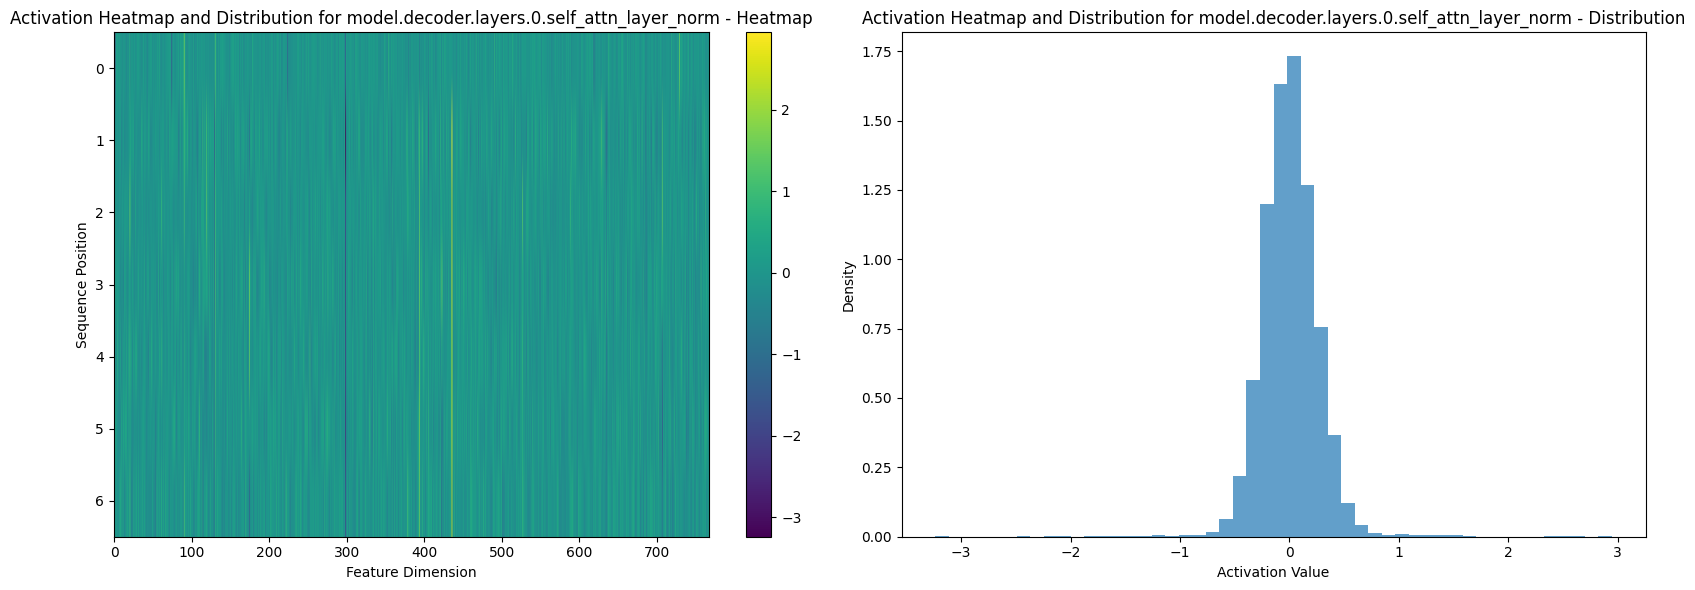

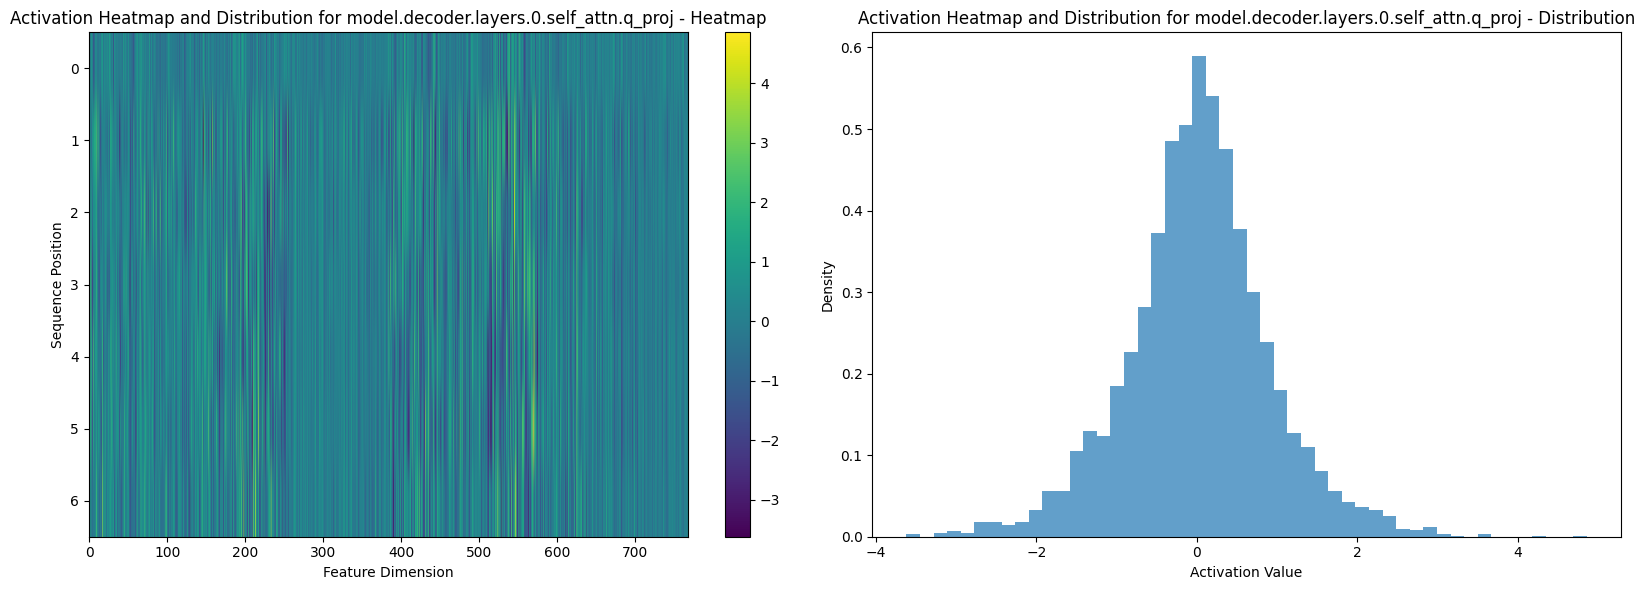

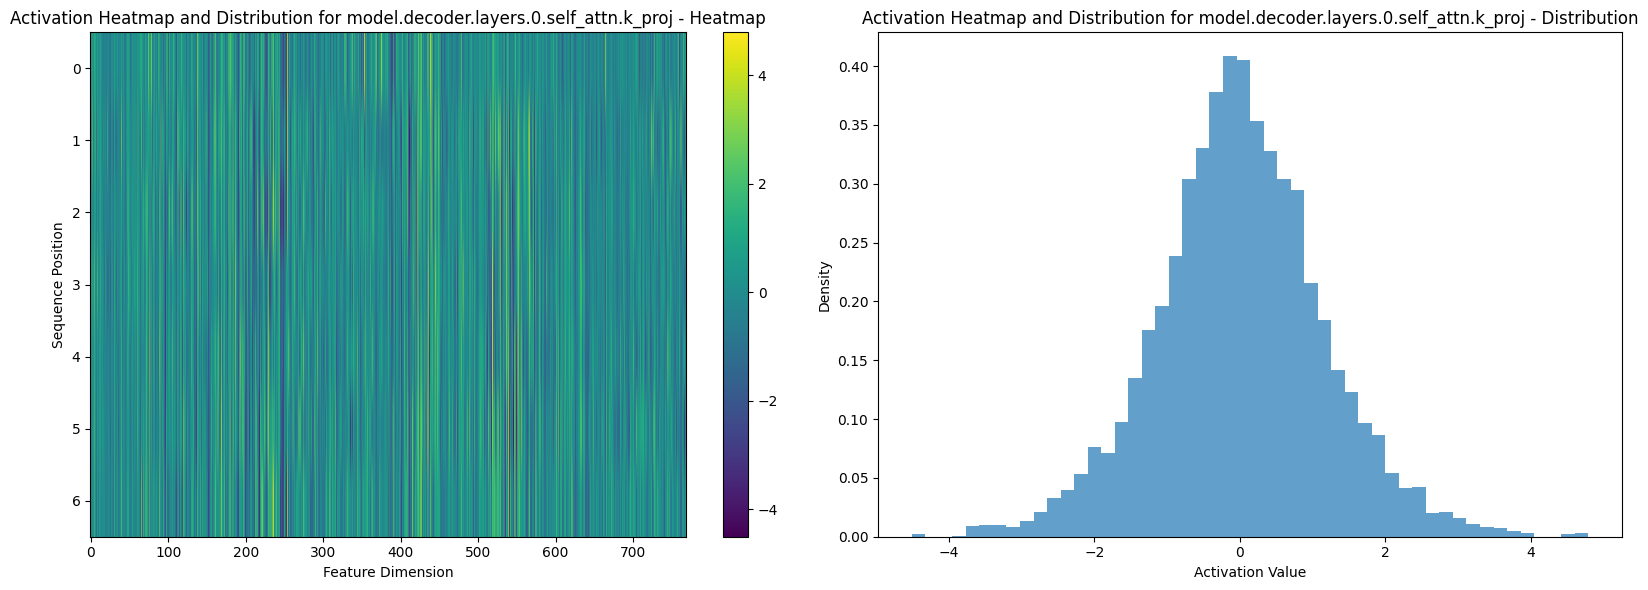

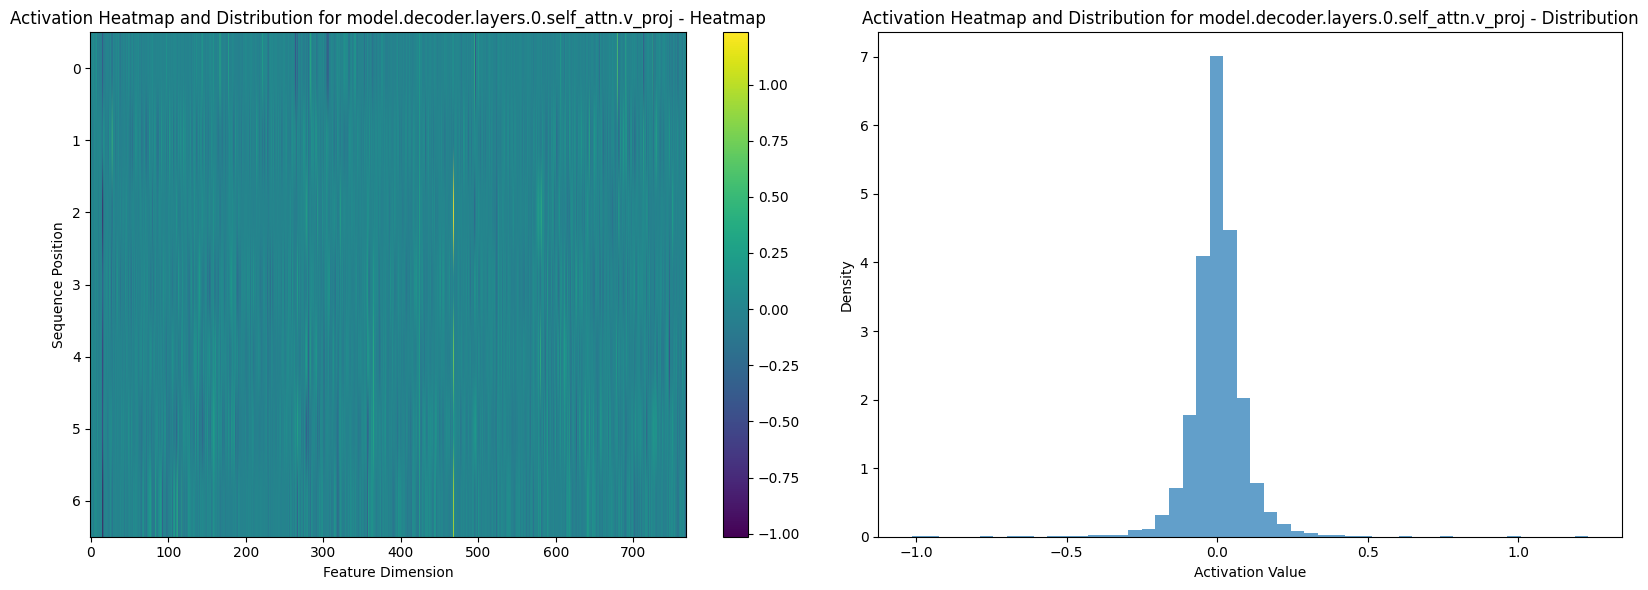

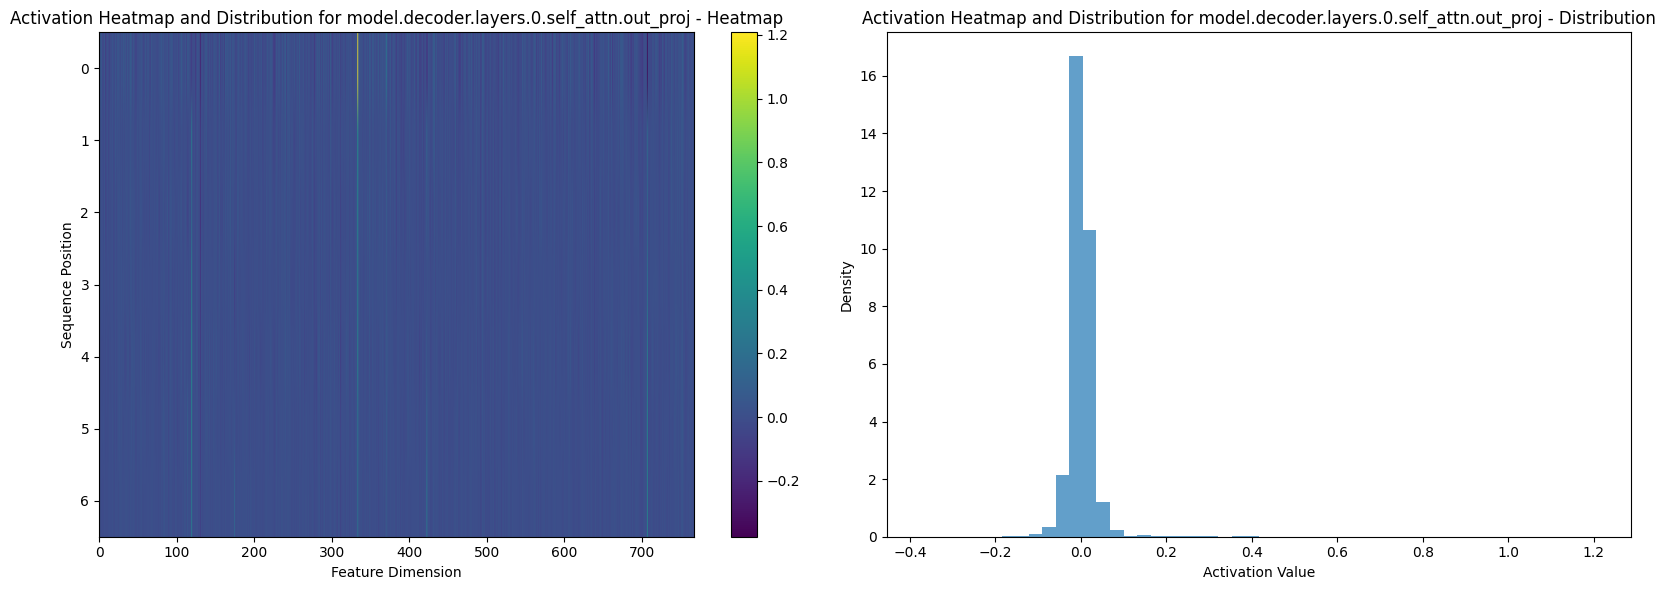

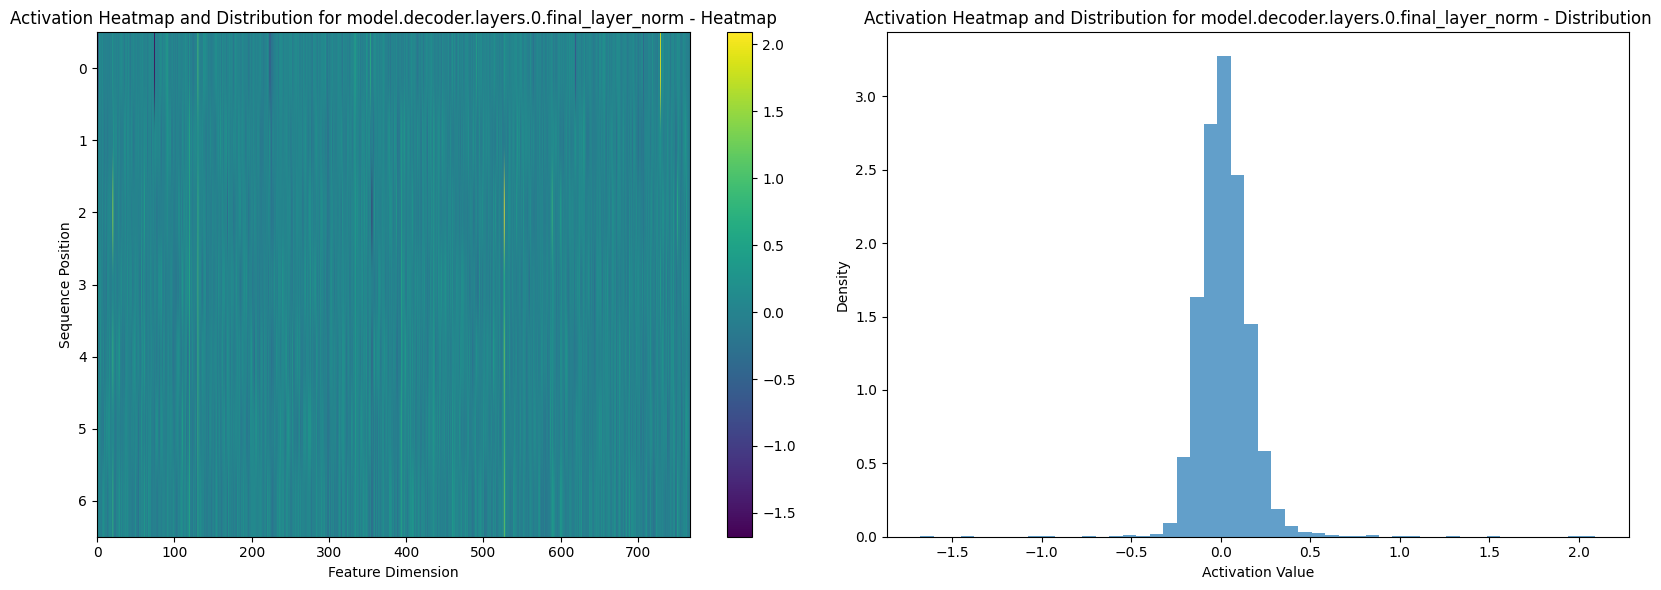

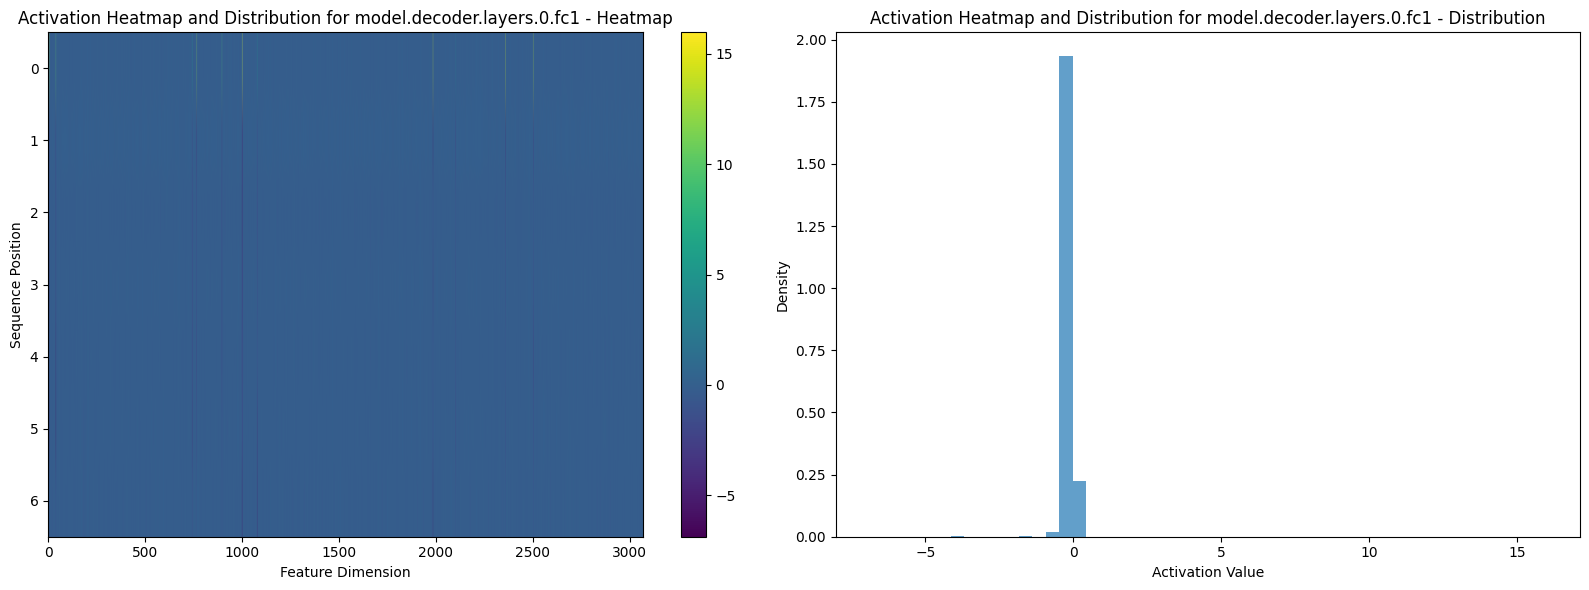

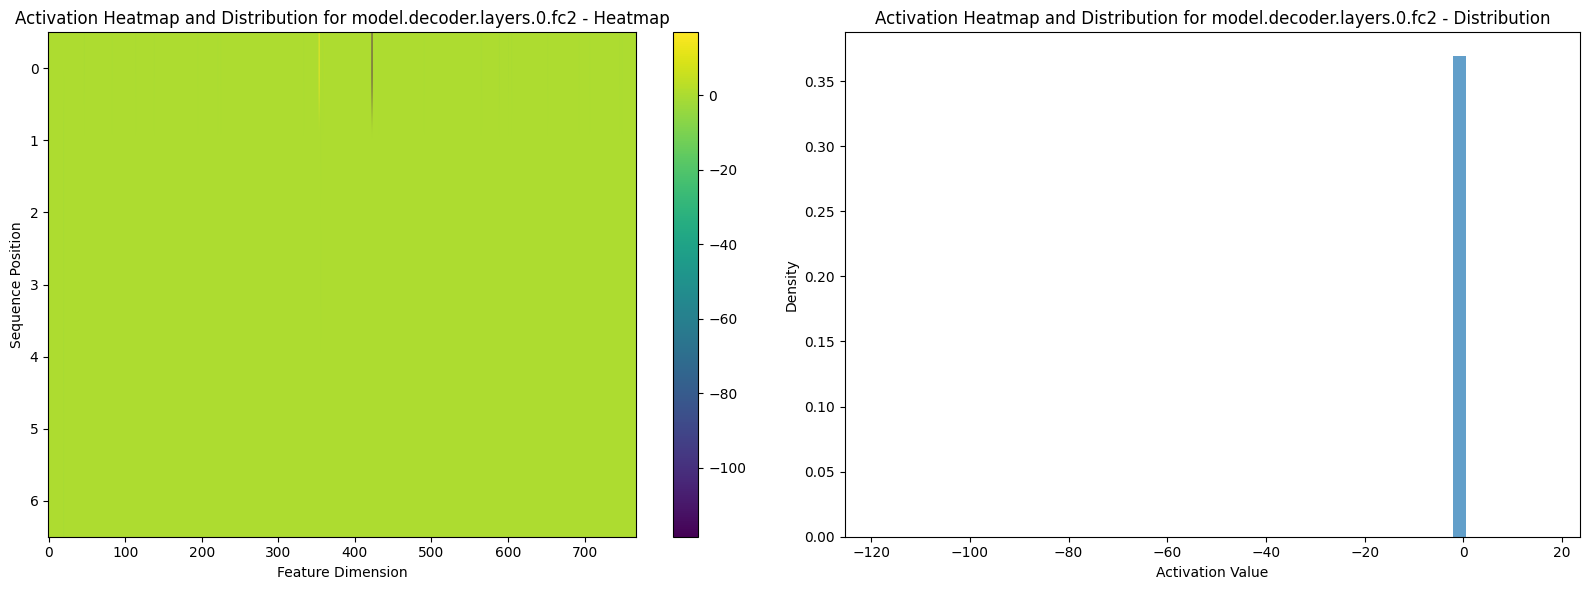

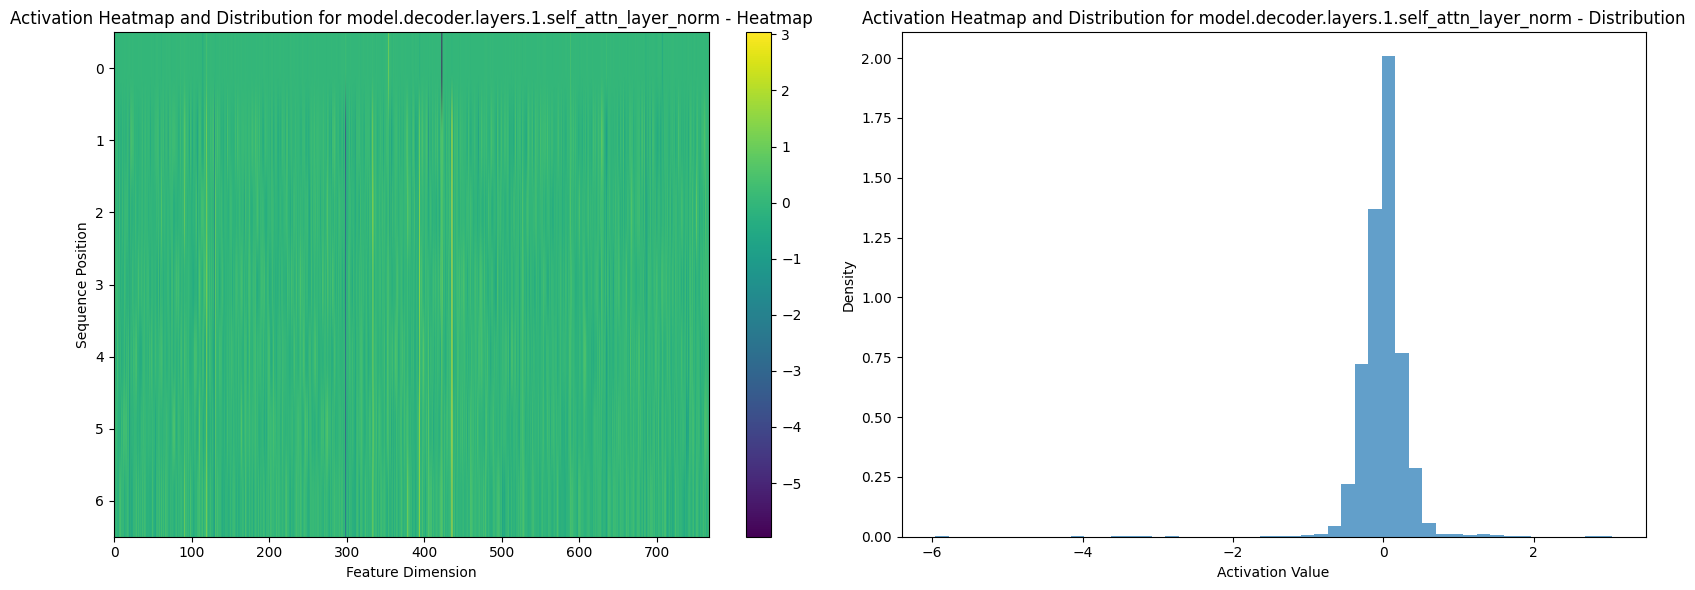

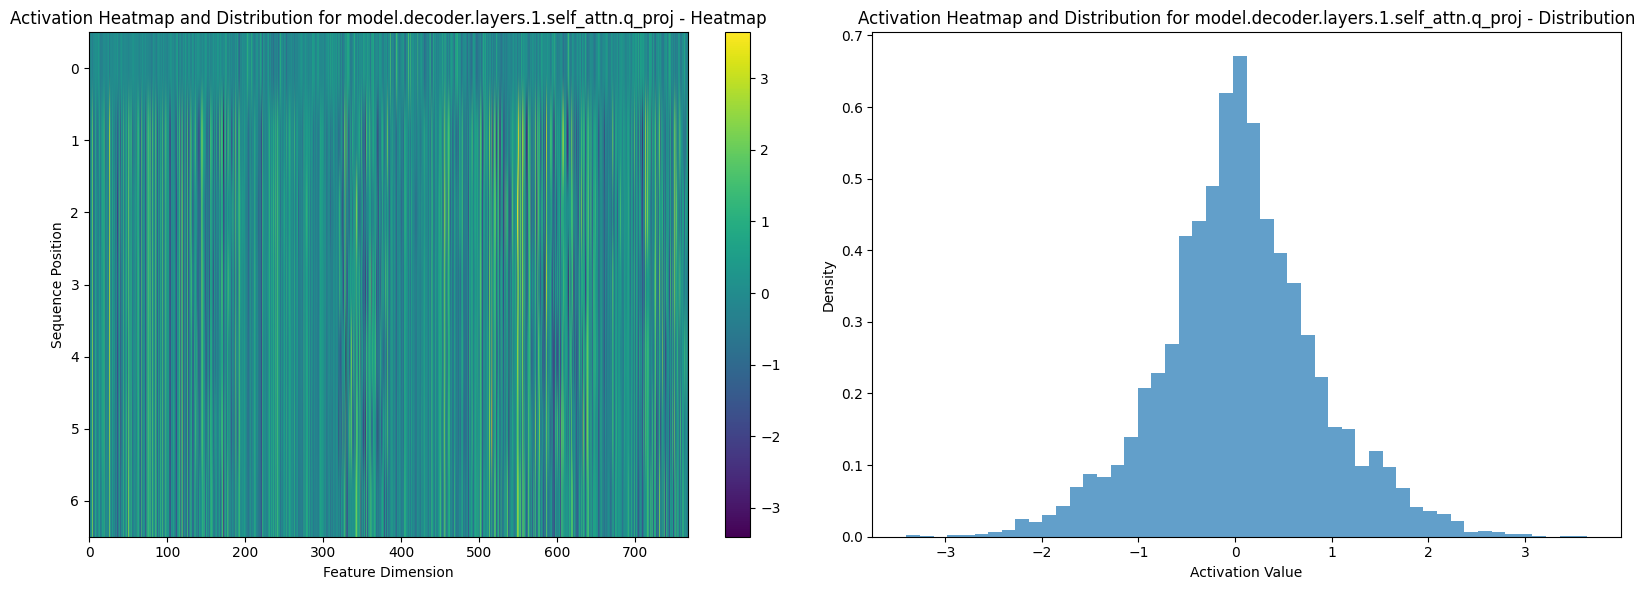

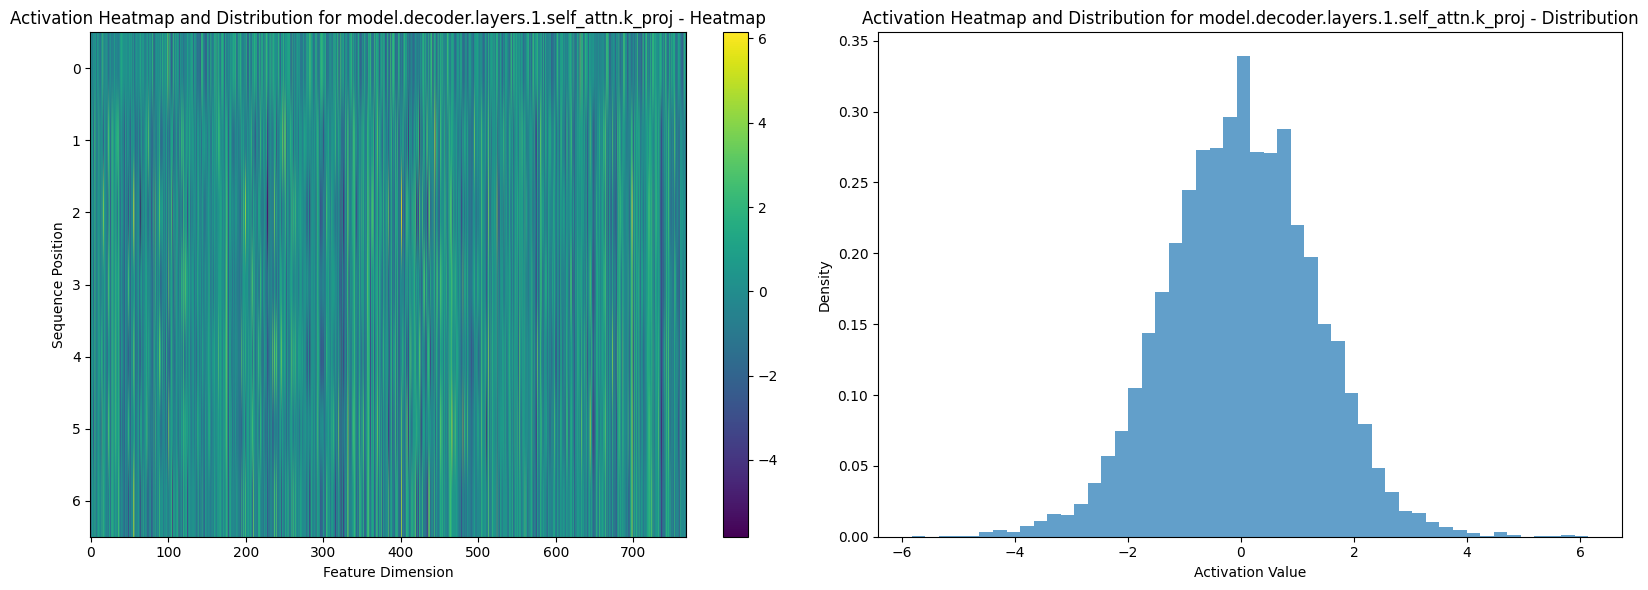

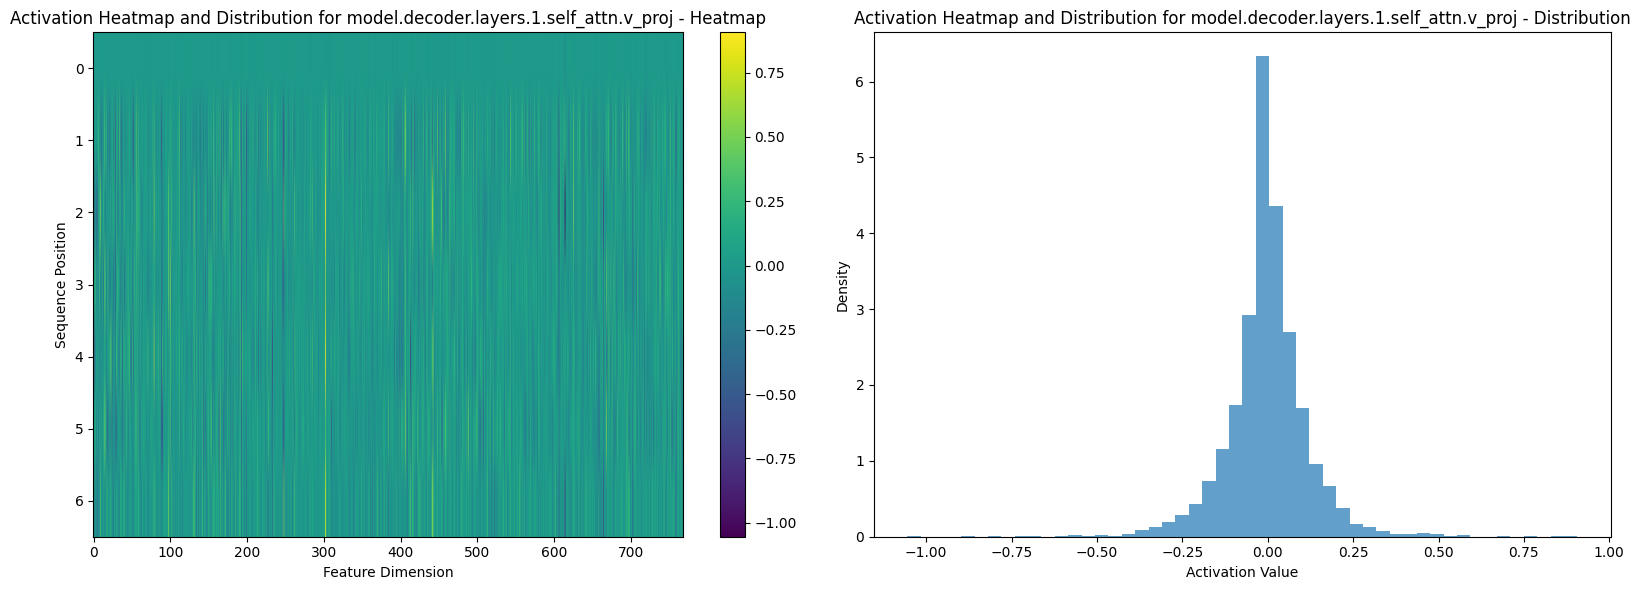

In [27]:
for i, (layer_name, activation) in enumerate(layer_activations.items()):
    plot_activation_heatmap_and_distribution_side_by_side(
        activation, title=f"Activation Heatmap and Distribution for {layer_name}"
    )
    if i > 10:
        break

### 3.6 LLM attention scores

**Implementation task:**
- Implement a function that collects the attention scores of the model for a specific input sentence.
- Repeat the experiment for multiple input sentences and LLMs.

**Questions:**
- What is the shape of the attention scores?

In [28]:
def collect_attention_scores(model, tokenizer, prompt):
    """
    Collect attention scores from all layers when processing a prompt.

    Args:
        model: The transformer model
        tokenizer: The tokenizer to use
        prompt: Input text prompt

    Returns:
        Dictionary mapping layer names to attention score tensors
    """
    attention_scores = {}

    ### To Complete ###
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    outputs = model(**inputs, output_attentions=True)
    for layer_idx, attention_layer in enumerate(outputs.attentions):
        layer_name = f"layer_{layer_idx}_attention"
        attention_scores[layer_name] = (
            attention_layer.detach().cpu()
        )  # Shape: (batch_size, num_heads, sequence_length, sequence_length)
    ### End of To Complete ###

    return attention_scores

In [29]:
attention_scores = collect_attention_scores(model, tokenizer, prompt)

# Print attention score shapes for each layer
for layer_name, attention_score in attention_scores.items():
    print(f"{layer_name}: {attention_score.shape}")

`torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True`. Falling back to eager attention. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


layer_0_attention: torch.Size([1, 12, 7, 7])
layer_1_attention: torch.Size([1, 12, 7, 7])
layer_2_attention: torch.Size([1, 12, 7, 7])
layer_3_attention: torch.Size([1, 12, 7, 7])
layer_4_attention: torch.Size([1, 12, 7, 7])
layer_5_attention: torch.Size([1, 12, 7, 7])
layer_6_attention: torch.Size([1, 12, 7, 7])
layer_7_attention: torch.Size([1, 12, 7, 7])
layer_8_attention: torch.Size([1, 12, 7, 7])
layer_9_attention: torch.Size([1, 12, 7, 7])
layer_10_attention: torch.Size([1, 12, 7, 7])
layer_11_attention: torch.Size([1, 12, 7, 7])


**Implementation task:**
- Implement plotting functions that represent the attention scores in the form of a heatmap of absolute values.
- Repeat the experiment for multiple input sentences and LLMs.

**Questions:**
- Does the attention heatmap shows some patterns?

In [30]:
def plot_attention_heatmap(attention_scores, layer_idx=0, head_idx=0):
    """
    Plot attention heatmap for a specific layer and attention head.

    Args:
        attention_scores: Dictionary of attention scores from collect_attention_scores()
        layer_idx: Index of the transformer layer to visualize (default: 0)
        head_idx: Index of the attention head to visualize (default: 0)
    """

    ### To Complete ###
    layer_name = f"layer_{layer_idx}_attention"
    attention_matrix = attention_scores[layer_name][
        0, head_idx
    ].numpy()  # Get first batch, selected head

    # Plot heatmap
    plt.figure(figsize=(10, 6))
    plt.imshow(attention_matrix, cmap="viridis", aspect="auto")
    plt.colorbar()
    plt.title(f"Attention Heatmap - Layer {layer_idx}, Head {head_idx}")
    plt.xlabel("Key tokens")
    plt.ylabel("Query tokens")
    plt.show()
    ### End of To Complete ###

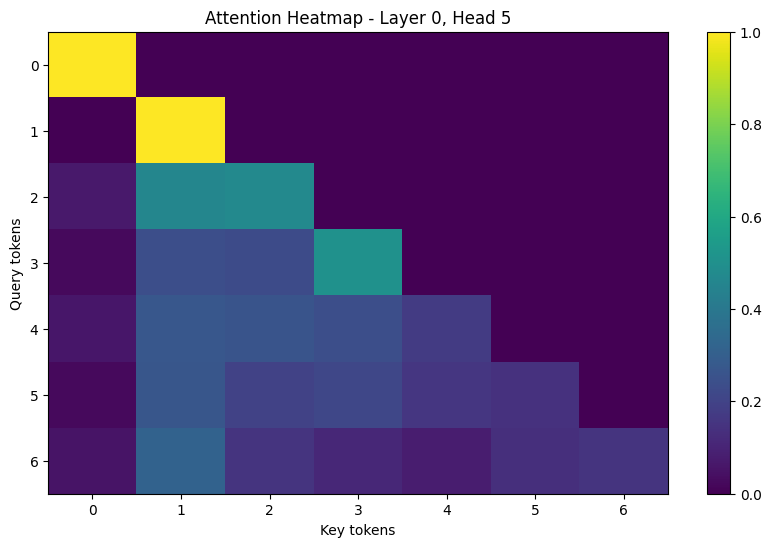

In [31]:
plot_attention_heatmap(attention_scores, layer_idx=0, head_idx=5)

## 4. Bonus: Make the architecture analysis on a quantized model